# RTSP To Insight: Decode, Encode, Annotate, Send

This notebook puts the three previous notebooks together into one working application, and along the way
covers everything a Neat application needs to know about **Insight**.

What you build:

```text
   RTSP camera                                                     Insight
   rtsp://host:8555/stream                                         (browser viewer)
        |                                                              ^
        |  H.264                                                       |
        v                                                              |
  +-------------------------+                             +------------------------+
  | groups.rtsp_decoded_    |   NV12 frames               |  video   UDP 9000 + ch |
  | input(...)              |------------+                |  metadata UDP 9100 + ch|
  +-------------------------+            |                +------------------------+
        notebook 02                      |                        ^         ^
                                         v                        |         |
                              +----------------------+  H.264/RTP |         | JSON
                              |  YOLOv8n detection   |            |         |
                              |  (optional)          |            |         |
                              +----------------------+            |         |
                                         |                        |         |
                          +--------------+-------------+          |         |
                          |                            |          |         |
                          v                            v          |         |
              +------------------------+   +------------------------+       |
              | groups.video_sender()  |---+ pyneat.MetadataSender  |-------+
              |   re-encode to H.264   |   |   JSON over UDP        |
              +------------------------+   +------------------------+
                     notebook 05                  notebook 06
```

Read one RTSP stream, decode it on the SiMa hardware decoder, optionally run detection on it, encode it
back to H.264, attach JSON metadata, and put both on the wire for Insight to render.

Prerequisites: notebook 02 (RTSP decode), notebook 05 (`video_sender`), notebook 06 (`MetadataSender`).

## Part 1 - What Insight Is, From A Neat Application's Point Of View

Insight is a service that ships with the Neat Development Environment. It has a web UI, a media server,
and a video viewer. For an application developer, only three of its surfaces matter:

| Surface | What it is | How your app uses it |
| --- | --- | --- |
| **Video ingest** | UDP ports `9000-9079`, one per channel | `video_sender` sends H.264/RTP here. |
| **Metadata ingest** | UDP ports `9100-9179`, one per channel | `MetadataSender` sends JSON here. |
| **Control/stats API** | HTTPS on port `9900` | You query it to prove your data arrived. |

There are two more that are useful but optional:

| Surface | What it is | When you want it |
| --- | --- | --- |
| **RTSP media server** | TCP `8554`, serves uploaded videos as `rtsp://host:8554/srcN` | You need a repeatable test stream and have no camera. |
| **Video viewer UI** | TCP `8081`, the WebRTC page that renders your channels | You want to see the result. |

Insight is a **receiver**. It never reaches into your application. Your app decides what to send, on
which channel, and when. Everything below is about getting those two UDP streams right.

### The Channel Rule

A **channel** is a small integer, `0` to `79`, that names one logical stream. It selects three things at
once:

```text
channel N  ->  video    on UDP  9000 + N
           ->  metadata on UDP  9100 + N
           ->  viewer tile src=N
```

Everything downstream depends on those three staying in agreement. If your video goes to channel 0 and
your metadata to channel 1, the video plays, the metadata arrives, and the boxes are drawn on the wrong
tile. Nothing errors. Derive both port numbers from a single `CHANNEL` variable and this class of bug
disappears.

### Do Not Assume The Default Ports

`9000`, `9100`, `8081`, `8554`, and `9900` are Insight's *container* ports. If those host ports were
already taken when the SDK started, `sima-cli` remaps them, and the ports your DevKit must send to are
the remapped ones. The port map is authoritative and machine-readable:

```bash
neat --json
```

Read `exposedPorts[*].hostPortStart`, not the documentation. The next section does that from Python.

## Part 2 - Imports And Settings

In [1]:
import json
import ssl
import subprocess
import time
import urllib.request
from pathlib import Path

import cv2
import numpy as np
import pyneat
from IPython.display import Image, display

`INSIGHT_HOST` is the machine running Insight, which is also the machine serving the RTSP stream in this
setup. It must be reachable from wherever this notebook's kernel runs.

In [2]:
RTSP_URL = "rtsp://192.168.131.12:8554/src1"  # The camera / test stream to consume.
INSIGHT_HOST = "192.168.131.12"  # Machine running Insight.

CHANNEL = 0  # One number drives video port, metadata port, and viewer tile.
VIDEO_PORT_BASE = 9000  # Overridden below from the live port map when available.
METADATA_PORT_BASE = 9100
INSIGHT_API = f"https://{INSIGHT_HOST}:9900"

MODEL_PATH = Path("../assets/models/yolo_v8n_mpk.tar.gz")  # Optional. Detection is skipped if missing.
LABELS_PATH = Path("../assets/coco_labels.txt")

FALLBACK_WIDTH = 1280  # Used only if the stream caps cannot be probed.
FALLBACK_HEIGHT = 720
FALLBACK_FPS = 30

MODEL_W = 640
MODEL_H = 640
SCORE_THRESHOLD = 0.35
NMS_IOU = 0.50
TOP_K = 50

FRAMES_TO_STREAM = 600  # About 20 seconds at 30 fps.

print("rtsp    :", RTSP_URL)
print("insight :", INSIGHT_HOST)
print("channel :", CHANNEL)

rtsp    : rtsp://192.168.131.12:8554/src1
insight : 192.168.131.12
channel : 0


## Part 3 - Insight Preflight

Four checks, in order. Each one rules out a whole class of failure, so run them before you write any
pipeline code. If a check fails here, no amount of graph debugging will help.

### 3.1 Is Insight Alive?

`/api/health` is the cheapest possible question. Insight serves HTTPS with a local mkcert certificate,
so a diagnostic client skips verification.

In [3]:
def insight_get(path: str, timeout: float = 5.0):
    ctx = ssl.create_default_context()
    ctx.check_hostname = False  # Local mkcert certificate; fine for a diagnostic call.
    ctx.verify_mode = ssl.CERT_NONE
    with urllib.request.urlopen(f"{INSIGHT_API}{path}", context=ctx, timeout=timeout) as response:
        return json.loads(response.read().decode("utf-8"))


INSIGHT_AVAILABLE = False
try:
    health = insight_get("/api/health")
    INSIGHT_AVAILABLE = health.get("status") == "ok"
    print("health:", json.dumps(health))
except Exception as exc:
    print("Insight not reachable:", type(exc).__name__, exc)
    print("The pipeline below will still build and run; only the viewer and stats cells need Insight.")

print("INSIGHT_AVAILABLE:", INSIGHT_AVAILABLE)

health: {"service": "neat-insight", "status": "ok", "time": "2026-07-16T10:14:49.318427Z"}
INSIGHT_AVAILABLE: True


### 3.2 What Ports Is It Really Listening On?

`neat --json` reports the SDK port map. Run it on the machine hosting the SDK. When this notebook runs on
a DevKit, the command is not present, and we fall back to the defaults, which is normally correct.

This cell is the one that prevents "everything looks right but nothing arrives".

In [4]:
def load_port_map():
    try:
        raw = subprocess.run(["neat", "--json"], capture_output=True, text=True, timeout=20, check=True)
    except Exception:
        return None
    try:
        return json.loads(raw.stdout)
    except json.JSONDecodeError:
        return None


port_map = load_port_map()
if port_map:
    ports = {entry["name"]: entry for entry in port_map.get("exposedPorts", [])}
    VIDEO_PORT_BASE = ports.get("videoUDP", {}).get("hostPortStart", VIDEO_PORT_BASE)
    METADATA_PORT_BASE = ports.get("metadataUDP", {}).get("hostPortStart", METADATA_PORT_BASE)
    print("port map from `neat --json`:")
    for name in ["mainUI", "videoUI", "rtsp.tcp", "videoUDP", "metadataUDP", "webRTC"]:
        entry = ports.get(name)
        if entry:
            end = entry.get("hostPortEnd")
            span = f"{entry['hostPortStart']}-{end}" if end else str(entry["hostPortStart"])
            print(f"  {name:14s} {entry['protocol']:4s} {span}")
else:
    print("`neat --json` unavailable (normal on a DevKit). Using default Insight ports.")

print()
print("video    ->", f"{INSIGHT_HOST}:{VIDEO_PORT_BASE + CHANNEL}")
print("metadata ->", f"{INSIGHT_HOST}:{METADATA_PORT_BASE + CHANNEL}")

port map from `neat --json`:

video    -> 192.168.131.12:9000
metadata -> 192.168.131.12:9100


### 3.3 Where Do I Watch The Result?

`/api/viewer-url` builds the viewer link with the correct, possibly remapped, `videoUI` port. Build the
link from the API rather than by hand, for the same reason as the ports above.

Open this URL in a browser and leave it open. The viewer must be attached for metadata to be forwarded
over the DataChannel; until a browser is watching, Insight receives your JSON but has nobody to give it to.

In [5]:
if INSIGHT_AVAILABLE:
    viewer = insight_get(f"/api/viewer-url?mode=light&src={CHANNEL}")
    viewer_url = viewer["url"].replace("127.0.0.1", INSIGHT_HOST)  # Make it reachable from your browser.
    print("Open this in a browser and keep it open:")
    print(" ", viewer_url)
else:
    print(f"  https://{INSIGHT_HOST}:8081/static/viewer.html?mode=light&src={CHANNEL}")

Open this in a browser and keep it open:
  https://192.168.131.12:8081/static/viewer.html?mode=light&src=0


## Part 4 - Probe The Stream

The decoder, the encoder, and the metadata coordinate space all need the same width, height, and frame
rate. Probe once, then derive everything from the result. Hard-coding these three numbers in three places
is the most reliable way to build a pipeline that negotiates but produces garbage.

In [6]:
def probe_rtsp(url: str):
    capture = cv2.VideoCapture(url)
    if capture.isOpened():
        width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
        height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
        fps = int(round(capture.get(cv2.CAP_PROP_FPS) or 0))
        capture.release()
        if width > 0 and height > 0:
            return width, height, fps if fps > 0 else FALLBACK_FPS
    return FALLBACK_WIDTH, FALLBACK_HEIGHT, FALLBACK_FPS


WIDTH, HEIGHT, FPS = probe_rtsp(RTSP_URL)
if WIDTH % 2 or HEIGHT % 2:
    raise RuntimeError(f"H.264 encoding needs even dimensions, got {WIDTH}x{HEIGHT}")

print(f"stream: {WIDTH}x{HEIGHT} @ {FPS} fps")
print("this is the coordinate space for every bbox you will send")

stream: 1280x720 @ 60 fps
this is the coordinate space for every bbox you will send


## Part 5 - Ingest: Decode The RTSP Stream

Straight from notebook 02. `rtsp_decoded_input` handles receive, depayload, parse, and hardware decode,
and hands you raw NV12 frames.

NV12 is the format to stay in. The decoder emits it, the encoder consumes it, and the model's
preprocessing can convert it on the MLA. Converting to BGR in Python and back costs real milliseconds per
frame and buys nothing unless you need OpenCV to draw.

In [7]:
def make_source_options(url: str, width: int, height: int, fps: int):
    opt = pyneat.RtspDecodedInputOptions()
    opt.url = url
    opt.latency_ms = 200  # Jitter buffer. Raise on a lossy network, lower for latency.
    opt.tcp = True  # RTSP over TCP: reliable, and it traverses most networks.
    opt.payload_type = 96  # Standard dynamic RTP payload type for H.264.
    opt.insert_queue = True  # Decouple receive from decode.
    opt.sync_mode = False  # Live: do not pace to the clock.
    opt.auto_caps_from_stream = True  # Prefer what the stream actually says.
    opt.fallback_h264_width = width  # Used only if caps cannot be detected.
    opt.fallback_h264_height = height
    opt.fallback_h264_fps = fps
    opt.out_format = pyneat.Format.NV12  # Decoder-native, encoder-native.
    opt.decoder_name = "decoder"  # Shows up in describe_backend().
    opt.decoder_raw_output = True  # We want pixels, not encoded bytes.
    opt.use_videoconvert = False  # Nothing to convert; stay in NV12.
    opt.use_videoscale = False  # Model preprocessing resizes; do not do it twice.
    opt.output_caps.enable = True  # Make the frame contract explicit.
    opt.output_caps.format = pyneat.Format.NV12
    opt.output_caps.width = width
    opt.output_caps.height = height
    opt.output_caps.fps = fps
    opt.output_caps.memory = pyneat.CapsMemory.SystemMemory
    return opt


source_graph = pyneat.Graph("insight_source")
source_graph.add(pyneat.groups.rtsp_decoded_input(make_source_options(RTSP_URL, WIDTH, HEIGHT, FPS)))
source_graph.add(pyneat.nodes.output("frame", pyneat.OutputOptions.latest()))  # Live: newest frame wins.

print(source_graph.describe())

0) RTSPInput  [rtsp://192.168.131.12:8554/src1]
1) Queue
2) H264Depacketize
3) Queue
4) H264CapsFixup
5) H264Decode
6) CapsRaw
7) Output  [frame]


`OutputOptions.latest()` is the live-stream choice. It keeps only the newest frame and drops anything
older. If your application is momentarily slower than the camera, you want to fall behind by dropping
frames, not by building a queue of stale ones that grows forever.

`RunOptions` says the same thing at the graph level.

In [8]:
run_options = pyneat.RunOptions()
run_options.preset = pyneat.RunPreset.Realtime  # Latency-oriented scheduling defaults.
run_options.queue_depth = 4  # Small live buffer.
run_options.overflow_policy = pyneat.OverflowPolicy.KeepLatest  # Drop stale, keep fresh.
run_options.output_memory = pyneat.OutputMemory.Owned  # We copy/inspect pulled frames.

source_run = source_graph.build(run_options)
print("source running")

[1/4] Initializing runtime...
[2/4] Building graph...
[3/4] Starting pipeline...


source running


[4/4] Graph ready (1498 ms)


Pull one frame and look at it. If this cell produces an image, the whole ingest half is proven and you can
stop worrying about the camera, the network, and the decoder.

decoded frame: 1280x720, nv12 buffer (1080, 1280)


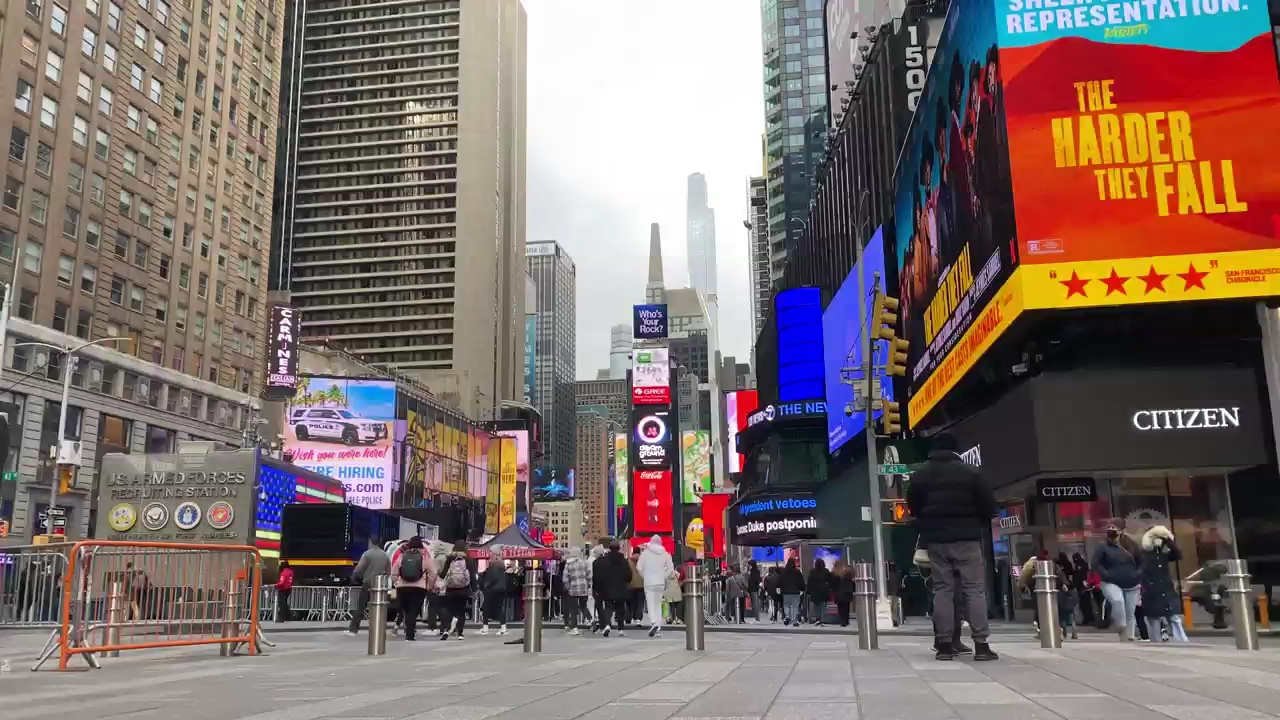

In [9]:
def tensor_to_nv12(tensor):
    width = int(tensor.width() if callable(tensor.width) else tensor.width)
    height = int(tensor.height() if callable(tensor.height) else tensor.height)
    payload = np.frombuffer(tensor.copy_payload_bytes(), dtype=np.uint8)
    expected = width * height * 3 // 2
    if payload.size < expected:
        raise RuntimeError(f"NV12 payload too small: {payload.size} < {expected}")
    return payload[:expected].reshape((height * 3 // 2, width)), width, height


tensors = source_run.pull_tensors("frame", timeout_ms=20000)
if not tensors:
    raise RuntimeError("no frame from RTSP. Check RTSP_URL and that the stream is running.")

nv12, frame_w, frame_h = tensor_to_nv12(tensors[0])
preview = cv2.cvtColor(nv12, cv2.COLOR_YUV2BGR_NV12)

print(f"decoded frame: {frame_w}x{frame_h}, nv12 buffer {nv12.shape}")
display(Image(data=cv2.imencode(".jpg", preview)[1].tobytes()))

## Part 6 - Egress: Encode It Back And Send It To Insight

Now the reverse direction, from notebook 05. Build a second graph that accepts NV12 and encodes to
H.264/RTP/UDP.

Two graphs, not one. The source graph pulls frames to Python; the video graph takes them back. Splitting
them is what gives your application a place to stand in the middle, where it can look at the pixels and
decide what to say about them. A single fused graph would be faster, but nothing in Python could see
the frames.

In [10]:
def make_nv12_input_options(width: int, height: int, fps: int):
    input_opt = pyneat.InputOptions()
    input_opt.payload_type = pyneat.PayloadType.Image
    input_opt.format = pyneat.Format.NV12
    input_opt.width = width
    input_opt.height = height
    input_opt.depth = 1
    input_opt.max_width = width
    input_opt.max_height = height
    input_opt.max_depth = 1
    input_opt.fps_n = max(1, fps)
    input_opt.fps_d = 1
    input_opt.caps_override = (
        f"video/x-raw,format=NV12,width={width},height={height},framerate={max(1, fps)}/1"
    )
    input_opt.use_simaai_pool = False
    return input_opt


def make_nv12_tensor(nv12, width: int, height: int):
    tensor = pyneat.Tensor.from_numpy(
        np.ascontiguousarray(nv12),
        copy=True,
        layout=pyneat.TensorLayout.HW,
        memory=pyneat.TensorMemory.EV74,
    )
    tensor.shape = [height, width]
    tensor.strides_bytes = [width, 1]
    tensor.byte_offset = 0

    image = pyneat.ImageSpec()
    image.format = pyneat.PixelFormat.NV12
    semantic = tensor.semantic
    semantic.image = image
    tensor.semantic = semantic

    y = pyneat.Plane()
    y.role = pyneat.PlaneRole.Y
    y.shape = [height, width]
    y.strides_bytes = [width, 1]
    y.byte_offset = 0

    uv = pyneat.Plane()
    uv.role = pyneat.PlaneRole.UV
    uv.shape = [height // 2, width]
    uv.strides_bytes = [width, 1]
    uv.byte_offset = width * height

    tensor.planes = [y, uv]
    return tensor


video_opt = pyneat.VideoSenderOptions.h264_rtp_udp_from_raw(WIDTH, HEIGHT, max(1, FPS))
video_opt.host = INSIGHT_HOST
video_opt.channel = CHANNEL  # Same channel as metadata, below.
video_opt.video_port_base = VIDEO_PORT_BASE
video_opt.encoder.bitrate_kbps = 4000
video_opt.encoder.profile = "baseline"  # Browser/WebRTC friendly: no B-frames.
video_opt.encoder.level = "4.0"
video_opt.rtp.payload_type = 96
video_opt.rtp.config_interval = 1  # Re-send SPS/PPS every second so a late viewer can start decoding.
video_opt.sync = False
video_opt.async_ = False

video_graph = pyneat.Graph("insight_video")
video_graph.add(pyneat.nodes.input(make_nv12_input_options(WIDTH, HEIGHT, FPS)))
video_graph.add(pyneat.groups.video_sender(video_opt))

# The video sender is a live egress path, so it must DROP under backpressure, not
# block. Without explicit run options a built graph defaults to OverflowPolicy.Block:
# if the H.264 encoder + UDP sink falls even slightly behind the push rate (here the
# stream negotiated 60 fps), the sender's internal edge queue fills and push() blocks
# past push_timeout_ms, raising "sink backpressure timeout" after a few hundred frames.
# KeepLatest drops the stale frame instead, matching the source/model runs and the
# notebook's live philosophy (fall behind by dropping, not by queueing stale frames).
video_run_options = pyneat.RunOptions()
video_run_options.preset = pyneat.RunPreset.Realtime
video_run_options.queue_depth = 4
video_run_options.overflow_policy = pyneat.OverflowPolicy.KeepLatest  # Live egress: drop stale, never block.

seed = np.full((HEIGHT * 3 // 2, WIDTH), 128, dtype=np.uint8)
seed[:HEIGHT, :] = 16
video_run = video_graph.build([make_nv12_tensor(seed, WIDTH, HEIGHT)], video_run_options)

print("video sender ->", f"{video_opt.host}:{video_opt.video_port}")

[1/4] Initializing runtime...
[2/4] Preparing input stream...
[3/4] Building graph...


video sender -> 192.168.131.12:9000


[4/4] Graph ready (46 ms)


## Part 7 - Metadata: Say Something About The Frame

From notebook 06. Same channel, different base port. `MetadataSender` is not part of any graph; it is an
object your loop calls.

In [11]:
meta_opt = pyneat.MetadataSenderOptions()
meta_opt.host = INSIGHT_HOST
meta_opt.channel = CHANNEL  # Same CHANNEL as the video sender. This is what pairs them.
meta_opt.metadata_port_base = METADATA_PORT_BASE

metadata_sender = pyneat.MetadataSender(meta_opt)

print("metadata sender ->", f"{metadata_sender.host()}:{metadata_sender.metadata_port()}")
print("video sender    ->", f"{video_opt.host}:{video_opt.video_port}")
print("channels match  :", video_opt.channel == meta_opt.channel)

metadata sender -> 192.168.131.12:9100
video sender    -> 192.168.131.12:9000
channels match  : True


## Part 8 - Detection (Optional)

If `yolo_v8n_mpk.tar.gz` is in `../assets/models/`, run real detection on the decoded frames. If not, the
notebook falls back to synthetic metadata, and everything else still works. The pipeline shape is
identical either way; only the source of the boxes changes.

The model consumes NV12 directly. `ModelOptions` handles the NV12-to-RGB conversion, the letterbox resize
from stream resolution to 640x640, the COCO normalization, and the box decode. Doing any of that in
Python would be slower and would put the boxes in the wrong coordinate space.

In [12]:
def load_labels(path: Path):
    if path.exists():
        return [line.strip() for line in path.read_text().splitlines() if line.strip()]
    return []


LABELS = load_labels(LABELS_PATH)
DETECTION_ENABLED = MODEL_PATH.exists()
# DETECTION_ENABLED = False

model = None
model_run = None

if DETECTION_ENABLED:
    model_opt = pyneat.ModelOptions()
    model_opt.preprocess.kind = pyneat.InputKind.Image  # Pixels, not model-shaped tensors.
    model_opt.preprocess.enable = pyneat.AutoFlag.On
    model_opt.preprocess.input_max_width = WIDTH
    model_opt.preprocess.input_max_height = HEIGHT
    model_opt.preprocess.input_max_depth = 1
    model_opt.preprocess.color_convert.enable = pyneat.AutoFlag.On
    model_opt.preprocess.color_convert.input_format = pyneat.PreprocessColorFormat.NV12  # Decoder output.
    model_opt.preprocess.color_convert.output_format = pyneat.PreprocessColorFormat.RGB  # Model contract.
    model_opt.preprocess.resize.enable = pyneat.AutoFlag.On
    model_opt.preprocess.resize.width = MODEL_W
    model_opt.preprocess.resize.height = MODEL_H
    model_opt.preprocess.resize.mode = pyneat.ResizeMode.Letterbox  # Preserve aspect ratio: box geometry matters.
    model_opt.preprocess.preset = pyneat.NormalizePreset.COCO_YOLO
    model_opt.decode_type = pyneat.BoxDecodeType.YoloV8  # Neat decodes the heads for us.
    model_opt.score_threshold = SCORE_THRESHOLD
    model_opt.nms_iou_threshold = NMS_IOU
    model_opt.top_k = TOP_K
    model_opt.num_classes = 80
    model_opt.verbose = pyneat.VerboseOptions.quiet()

    model = pyneat.Model(str(MODEL_PATH), model_opt)

    model_graph = pyneat.Graph("insight_model")
    model_graph.add(pyneat.nodes.input(make_nv12_input_options(WIDTH, HEIGHT, FPS)))
    model_graph.add(model)
    model_graph.add(pyneat.nodes.output("detections", pyneat.OutputOptions.every_frame(4)))
    model_run = model_graph.build(run_options)
    print("detection enabled:", MODEL_PATH)
    print("labels loaded:", len(LABELS))
else:
    print("Model not found at", MODEL_PATH)
    print("Falling back to synthetic metadata. The pipeline is otherwise identical.")

detection enabled: ../assets/models/yolo_v8n_mpk.tar.gz
labels loaded: 80


Pipeline:
rtspsrc name=n0_rtspsrc_1 location="rtsp://192.168.131.12:8554/src1" latency=200 protocols=tcp ! queue name=n1_queue_1 ! capsfilter name=n2_rtp_caps_1 caps="application/x-rtp,media=video,encoding-name=H264,payload=96" ! rtph264depay name=n2_depay_1 wait-for-keyframe=true ! identity name=n2_h264_segment_1 silent=true single-segment=true ! h264parse name=n2_h264parse_1 disable-passthrough=true ! capsfilter name=n2_h264_caps_1 caps="video/x-h264,parsed=true,stream-format=(string)byte-stream,alignment=(string)au" ! queue name=n3_queue_1 ! identity name=n4_h264_capsfix_1 silent=true ! neatdecoder name=decoder_1 sima-allocator-type=2 op-buff-name=decoder_1 dec-fmt=NV12 dec-width=1280 dec-height=720 dec-fps=60 ! capsfilter name=n6_caps_1 caps="video/x-raw(memory:SystemMemory),format=NV12,width=1280,height=720,framerate=60/1" ! appsink name=mysink_1 emit-signals=false sync=false max-buffers=4 drop=false enable-last-sample=false
[1/4] Initializing runtime...
[2/4] Building graph...
[3

### From Model Output To Insight Coordinates

Two conversions stand between `decode_bbox` and a box the viewer draws in the right place.

**Coordinate space.** The model saw a letterboxed 640x640 image, but you need coordinates in the
**encoded frame's** pixel space, because that is what the viewer scales from. `decode_bbox(...,
clamp_to=(WIDTH, HEIGHT))` does that for you: it undoes the letterbox using the preprocess metadata Neat
recorded, and returns coordinates in the original frame.

**Box format.** `decode_bbox` returns corners, `x1, y1, x2, y2`. Insight wants top-left plus size,
`[x, y, w, h]`. Forgetting this produces boxes of plausible size in visibly wrong positions, and it is the
single most common overlay bug.

In [13]:
def decode_boxes(tensors, width: int, height: int, top_k: int):
    decoded = pyneat.decode_bbox(tensors, clamp_to=(width, height), top_k=top_k)  # -> frame pixel space.
    boxes = []
    for tensor in decoded:
        rows = np.asarray(tensor.to_numpy(copy=True), dtype=np.float32).reshape((-1, 6))
        for x1, y1, x2, y2, score, class_id in rows:
            if x2 <= x1 or y2 <= y1:
                continue
            boxes.append({
                "x1": float(x1), "y1": float(y1), "x2": float(x2), "y2": float(y2),
                "score": float(score), "class_id": int(class_id),
            })
    return boxes[:top_k]


def class_label(class_id: int) -> str:
    if 0 <= class_id < len(LABELS):
        return LABELS[class_id]
    return f"class_{class_id}"


def object_detection_payload(boxes, min_score: float):
    objects = []
    for index, box in enumerate(boxes):
        if box["score"] < min_score:
            continue
        objects.append({
            "id": f"obj_{index + 1}",
            "label": class_label(box["class_id"]),
            "confidence": round(box["score"], 3),
            # corners -> [x, y, w, h], which is what the Insight viewer expects.
            "bbox": [
                int(box["x1"]),
                int(box["y1"]),
                int(box["x2"] - box["x1"]),
                int(box["y2"] - box["y1"]),
            ],
        })
    # An empty list is meaningful: it clears the previous overlay.
    return {"objects": objects}


def synthetic_payload(index: int, width: int, height: int):
    x = 100 + (index * 9) % max(1, width - 360)
    return {"objects": [{
        "id": "obj_1",
        "label": "synthetic",
        "confidence": 0.99,
        "bbox": [int(x), int(height * 0.4), 240, 180],
    }]}


print("payload builders ready")

payload builders ready


## Part 9 - The Full Loop

Everything above, once per frame:

```text
pull decoded NV12
  -> push to model, pull detections        (if the model is present)
  -> push the same NV12 to the video sender  -> Insight video   channel N
  -> send the detections as JSON             -> Insight metadata channel N
```

Note what is **not** in the loop: no drawing. The boxes are not burned into the pixels. Insight's viewer
draws them client-side from the metadata, on a canvas over the video. That means the video stays clean, the
overlay stays crisp at any zoom, and a downstream consumer can use your detections as data rather than
having to un-see them. Draw into the frame only when the receiver cannot render an overlay itself.

The loop also times each stage. If throughput disappoints, the stage timings tell you where it went
before you start guessing.

In [14]:
FRAMES_TO_STREAM = 2000
# DETECTION_ENABLED = False

In [15]:
frame_w, frame_h

(1280, 720)

In [16]:
stats = {"decode_ms": 0.0, "infer_ms": 0.0, "encode_ms": 0.0, "meta_ms": 0.0}
processed = 0
detection_total = 0
started_at = time.perf_counter()

try:
    for index in range(FRAMES_TO_STREAM):
        t0 = time.perf_counter()
        tensors = source_run.pull_tensors("frame", timeout_ms=20000)
        if not tensors:
            print("[warn] timed out waiting for an RTSP frame")
            continue
        nv12, frame_w, frame_h = tensor_to_nv12(tensors[0])
        nv12 = np.ascontiguousarray(nv12).copy()
        t1 = time.perf_counter()

        boxes = []
        if DETECTION_ENABLED:
            if model_run.push([make_nv12_tensor(nv12, frame_w, frame_h)]):
                detections = model_run.pull_tensors("detections", timeout_ms=20000)
                if detections:
                    boxes = decode_boxes(detections, frame_w, frame_h, TOP_K)
        t2 = time.perf_counter()

        # Same pixels back out: decoded -> re-encoded H.264 -> RTP/UDP -> Insight.
        if not video_run.push([make_nv12_tensor(nv12, frame_w, frame_h)]):
            print("[warn] video push rejected the frame")
        t3 = time.perf_counter()

        payload = (
            object_detection_payload(boxes, SCORE_THRESHOLD)
            if DETECTION_ENABLED
            else synthetic_payload(index, frame_w, frame_h)
        )
        metadata_sender.send_metadata(
            "object-detection",
            json.dumps(payload),
            int(time.time() * 1000),
            f"frame-{index}",  # Ties this JSON to the frame pushed one line above.
        )
        t4 = time.perf_counter()

        stats["decode_ms"] += (t1 - t0) * 1000
        stats["infer_ms"] += (t2 - t1) * 1000
        stats["encode_ms"] += (t3 - t2) * 1000
        stats["meta_ms"] += (t4 - t3) * 1000
        processed += 1
        detection_total += len(payload["objects"])

        if processed % 100 == 0:
            print(f"frame {processed}: {len(payload['objects'])} objects")
except KeyboardInterrupt:
    print("interrupted")

elapsed = time.perf_counter() - started_at
print()
print(f"frames streamed : {processed}")
print(f"objects sent    : {detection_total}")
print(f"wall clock      : {elapsed:.1f}s  ({processed / max(elapsed, 1e-6):.1f} fps)")
if processed:
    print()
    for stage in ["decode_ms", "infer_ms", "encode_ms", "meta_ms"]:
        print(f"  {stage:10s} {stats[stage] / processed:6.2f} ms/frame avg")

Configuring for the decoding type: 5:yolov8
Configured for subtensors: 6
Derived configuration for YOLO : num_anchors: 1 score tensor: 1 xy_tensor 0 extent_tensor 0
Additional configuration for YOLO : none
frame 100: 13 objects
frame 200: 12 objects


Pipeline:
appsrc name=mysrc_5 is-live=true format=time do-timestamp=true block=true stream-type=stream max-bytes=0 caps="video/x-raw,format=NV12,width=1280,height=720,framerate=60/1" ! neatprocesscvu name=preproc_5 stage-id=preproc_5 num-buffers=4 async=true  ! neatprocessmla name=MLA_0_5 stage-id=MLA_0_5 model-path="/tmp/simaai/coprocessing/models/proc_2619/yolo_v8n_mpk/share/yolo_v8n_stage1_mla.elf" batch-size=1 batch-sz-model=1 multi-pipeline=true  num-buffers=4  async=true  defer-output-invalidate=true  ! neatobjectdecode name=boxdecode_5 stage-id=boxdecode_5 silent=true emit-signals=false sima-allocator-type=2 transmit=false model-width=640 model-height=640 ! appsink name=mysink_5 emit-signals=false sync=false max-buffers=4 drop=false enable-last-sample=false


RuntimeError: [runtime.pull] [runtime.pull] GraphRun: sink backpressure timeout (node=0, edge_queue=256, push_timeout_ms=5000). This can happen because of graph backpressure: downstream stages, appsinks, or the application are not draining outputs as fast as inputs are pushed, so an internal edge/pipeline queue filled before the timeout. Pull outputs concurrently, reduce the push rate, increase GraphRunOptions.edge_queue/push_timeout_ms, or remove/relax slow downstream stages.

## Part 10 - Prove It Arrived

Both senders return `True` when the datagram leaves the socket. Neither can tell you it was received;
that is what UDP means. Insight's stats endpoints answer the question properly, and they answer it in a
specific order. Work down this list and stop at the first thing that is wrong.

### 10.1 Ingest: Did The Bytes Reach Insight?

`/api/ingest/stats` reports what Insight's vf process actually received on the UDP ports, before any
browser is involved.

| Field | Healthy | Meaning if not |
| --- | --- | --- |
| `rtp.packets_received` | climbing | Nothing arrived. Wrong host or port, or a firewall. |
| `rtp.bitrate_bps` | nonzero | The stream stalled. |
| `media.seen_sps` / `seen_pps` | `true` | No stream headers, so no decoder can start. Set `rtp.config_interval = 1`. |
| `media.idr_count` | growing | No keyframes; a viewer joining late will never get a first picture. |
| `metadata.messages_received` | climbing | Your JSON is not arriving. Check the metadata port. |
| `metadata.messages_forwarded` | climbing | Arriving, but no browser is attached to receive it. Open the viewer. |

The last two lines are the ones people misread. If `received` grows and `forwarded` does not, your
application is correct and the browser simply is not there.

In [ ]:
if INSIGHT_AVAILABLE:
    ingest = insight_get("/api/ingest/stats?all=1")
    found = False
    for channel in ingest.get("channels", []):
        if channel.get("channel") != CHANNEL:
            continue
        found = True
        rtp = channel.get("rtp", {})
        media = channel.get("media", {})
        meta = channel.get("metadata", {})
        forwarding = channel.get("forwarding", {})

        print(f"channel {CHANNEL}")
        print("  video")
        print("    packets_received :", rtp.get("packets_received"))
        print("    bitrate_bps      :", rtp.get("bitrate_bps"))
        print("    seen_sps/seen_pps:", media.get("seen_sps"), "/", media.get("seen_pps"))
        print("    idr_count        :", media.get("idr_count"))
        print("    webrtc track     :", forwarding.get("webrtc_track_attached"))
        print("  metadata")
        print("    messages_received :", meta.get("messages_received"))
        print("    messages_forwarded:", meta.get("messages_forwarded"))
        print("    invalid_json      :", meta.get("invalid_json"))
        print()
        if not rtp.get("packets_received"):
            print("  -> No RTP. Check host/port and the firewall between here and Insight.")
        elif not media.get("seen_sps"):
            print("  -> RTP but no SPS/PPS. Set video_opt.rtp.config_interval = 1.")
        elif meta.get("messages_received") and not meta.get("messages_forwarded"):
            print("  -> Video and metadata are both arriving. Open the viewer to see the overlay.")
        else:
            print("  -> Ingest looks healthy.")
        break
    if not found:
        print(f"channel {CHANNEL} is not reported. Nothing arrived on either port.")
else:
    print("Skipped: Insight not reachable.")

### 10.2 Egress: Did The Browser Decode It?

Only ask this once ingest is healthy. `/api/egress/stats` reports what Insight sent to the browser and
what the browser reported back via `RTCPeerConnection.getStats()`.

| Field | Meaning |
| --- | --- |
| `frames_decoded` | The browser decoded your H.264. Climbing means it works. |
| `frames_dropped` | Rising fast means the browser cannot keep up. Lower the bitrate or frame rate. |
| `pli_count` / `fir_count` | The browser is begging for a keyframe. Usually a missing or too-rare IDR. |
| `nack_count` | Packet loss on the path. |
| `metadata.dropped_no_data_channel` | Metadata Insight had to throw away because no browser was listening. |

Ingest healthy plus `frames_decoded` at zero means the bytes are fine but the browser cannot use them.
That is almost always a profile or keyframe problem, not a network one.

These peer fields come from the `vf` process, and their nesting has changed between Insight versions.
The cell below searches for the leaf names instead of hard-coding a path, and prints one peer verbatim
so you can see the shape your Insight build actually returns.

In [ ]:
def find_stat(node, key):
    """vf nests these under peer.browser / peer.rtcp; search rather than assume a path."""
    if isinstance(node, dict):
        if key in node:
            return node[key]
        for value in node.values():
            found = find_stat(value, key)
            if found is not None:
                return found
    elif isinstance(node, list):
        for item in node:
            found = find_stat(item, key)
            if found is not None:
                return found
    return None


if INSIGHT_AVAILABLE:
    try:
        egress = insight_get("/api/egress/stats?all=1&verbose=1")
        channels = [c for c in egress.get("channels", []) if c.get("channel") == CHANNEL]
        if not channels or not channels[0].get("peers"):
            print(f"No peers on channel {CHANNEL}. No browser is attached, so there is nothing to")
            print("deliver to. Open the viewer URL from Part 3.3 and re-run the streaming loop.")
        for channel in channels:
            peers = channel.get("peers", [])
            print(f"channel {CHANNEL}: {len(peers)} peer(s)")
            for peer in peers:
                print("  connection_state:", find_stat(peer, "connection_state"))
                print("  frames_decoded  :", find_stat(peer, "frames_decoded"))
                print("  frames_dropped  :", find_stat(peer, "frames_dropped"))
                print("  frames_per_second:", find_stat(peer, "frames_per_second"))
                print("  pli / fir / nack:", find_stat(peer, "pli_count"),
                      find_stat(peer, "fir_count"), find_stat(peer, "nack_count"))
            meta = channel.get("metadata", {})
            print("  metadata dropped (no DataChannel):", meta.get("dropped_no_data_channel"))

        # The exact nesting is vf's, not Neat's, and it can change between Insight versions.
        # Print one peer verbatim the first time you run this, so you can see the real shape.
        if channels and channels[0].get("peers"):
            print()
            print("raw peer object:")
            print(json.dumps(channels[0]["peers"][0], indent=2)[:1200])
    except Exception as exc:
        print("egress query failed:", type(exc).__name__, exc)
else:
    print("Skipped: Insight not reachable.")

## Part 11 - Shut Down

Each `Run` holds hardware: a decoder, an encoder, an open UDP socket. Stop them. In a notebook this
matters more than in a script, because the kernel outlives the cell and the next build will contend with
whatever you left running.

Send an empty metadata payload first. Without it, the last boxes you sent stay painted on the viewer
forever, which is a confusing thing to leave behind.

In [ ]:
metadata_sender.send_metadata(
    "object-detection",
    json.dumps({"objects": []}),  # Clear the overlay before we go.
    int(time.time() * 1000),
    "frame-final",
)

video_run.stop()
source_run.stop()
if model_run is not None:
    model_run.stop()

print("stopped: source, video sender", "and model" if model_run else "")

## Troubleshooting

Work down the table. Each row assumes the rows above it passed.

| Symptom | Check | Fix |
| --- | --- | --- |
| No frame from `pull_tensors` | Is the RTSP URL reachable? | `ffprobe -rtsp_transport tcp <url>`. Check `tcp = True`. |
| Frames pull, viewer tile is black | `/api/ingest/stats`: `packets_received` | If zero: wrong host or port, or a firewall. Confirm the port map with `neat --json`. |
| Packets arrive, viewer still black | `media.seen_sps` / `seen_pps` | Set `video_opt.rtp.config_interval = 1` so a late viewer gets stream headers. |
| Video plays, no boxes | `metadata.messages_received` | If zero, the metadata port is wrong. If nonzero, check `messages_forwarded`. |
| `messages_received` up, `messages_forwarded` flat | Is a browser attached? | Open the viewer URL. vf has nowhere to forward until then. |
| Boxes on the wrong tile | `video_opt.channel == meta_opt.channel`? | Derive both from one `CHANNEL`. |
| Boxes in the wrong place | Did you send `[x1,y1,x2,y2]`? | Insight wants `[x, y, w, h]`. Convert. |
| Boxes uniformly too small or offset | Coordinates in model space? | `decode_bbox(..., clamp_to=(WIDTH, HEIGHT))`. |
| Boxes freeze on the last detection | Are you sending on empty frames? | Send `{"objects": []}` every frame with no detections. |
| Browser stutters, `frames_dropped` climbs | Bitrate or frame rate too high. | Lower `encoder.bitrate_kbps`, or drop frames before pushing. |
| Latency grows over time | `sync` or `async_` set on a live path. | Both `False`. Use `OutputOptions.latest()` and `OverflowPolicy.KeepLatest`. |
| Throughput below the camera's rate | Stage timings from Part 9. | The largest average is where the time is going. Look there first. |

Two independent sanity checks, if you want to bisect the system:

```bash
# Known-good metadata, so you can tell a payload bug from a transport bug.
neat-insight-metadata-test --count 1 --types object-detection --fps 30
```

and the UDP loopback probe in notebook 05, which proves the video sender without involving the network.

## What To Remember

- The channel is the unit of pairing. One `CHANNEL` variable drives video port, metadata port, and viewer
  tile. Split them and you get silent, confusing bugs.
- Never assume Insight's ports. Read them from `neat --json`; `sima-cli` remaps them when the defaults are
  taken.
- Probe the stream once, then derive the decoder caps, the encoder contract, and the metadata coordinate
  space from that one result.
- Stay in NV12 from decoder to encoder. Convert to RGB inside the model's preprocessing, not in Python.
- Two graphs, one for ingest and one for egress, give your application a place to stand between them.
- Do not burn boxes into the pixels. Send them as metadata and let the viewer draw them: the video stays
  clean and the detections stay usable as data.
- `decode_bbox` returns corners in frame space. Insight wants `[x, y, w, h]`. Convert every time.
- Send metadata on every frame, including frames with nothing in them.
- A successful send proves the datagram left, nothing more. `/api/ingest/stats` proves it arrived, and
  `/api/egress/stats` proves the browser could use it. Check them in that order.
- Stop every `Run`. Decoders, encoders, and sockets do not free themselves when a cell finishes.

## References

- Notebook 02, `02_rtsp_input_and_decode_options.ipynb` - RTSP ingest and decode options.
- Notebook 05, `05_video_sender_options.ipynb` - `video_sender` and its option surface.
- Notebook 06, `06_metadata_sender_options.ipynb` - `MetadataSender` and the JSON payload shapes.
- App [`apps/multi-stream-yolo-yolo11`](../../apps/multi-stream-yolo-yolo11/README.md) - scaling this to many streams.
- Demo app: `apps/single-stream-yolo-yolo11/main.py`.
- Insight user documentation: https://developer.sima.ai/software/tools/insight/